In [77]:
# Importación de librerías necesarias (TP1 y TP2)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
import os
import pyarrow
import pyarrow.parquet as pq
import missingno
import openpyxl
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
from plotly.subplots import make_subplots
import plotly.graph_objects as go

#Librerías para TP3

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

In [78]:
# Construcción del path relativo al archivo (para que corra en cualquier entorno)
def get_data_path(filename):
    base_dir = os.path.dirname(os.getcwd())
    return os.path.join(base_dir, 'data', filename)


# filename = 'final_cured_df.csv'
filename = 'final_uncured_df.csv'


file_path = get_data_path(filename)
raw_df = pd.read_csv(file_path)


#vemos la estructura del dataset
print(f"Dimensiones: {raw_df.shape}")
print("\nTipos de datos:")
display(raw_df.dtypes)
display(raw_df.head())
# print("\nValores nulos:")
# print(raw_df.isnull().sum().head(52))

Dimensiones: (21060, 17)

Tipos de datos:


Unnamed: 0            int64
cliente               int64
produc               object
mes                  object
ventas_totales      float64
unidades_totales    float64
dias_con_venta      float64
dias_mes            float64
frecuencia_pct      float64
descrip              object
depo                float64
tipo_negocio        float64
lista_precios       float64
condi_venta          object
vende               float64
linea_nume          float64
sin_venta              bool
dtype: object

,Unnamed: 0,cliente,produc,mes,ventas_totales,unidades_totales,dias_con_venta,dias_mes,frecuencia_pct,descrip,depo,tipo_negocio,lista_precios,condi_venta,vende,linea_nume,sin_venta
0,0,4627,000-000-2001,2022-01,22.727986,12.0,1.0,31.0,0.032258,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
1,1,4627,000-000-2001,2022-02,48.113674,24.0,2.0,28.0,0.071429,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
2,2,4627,000-000-2001,2022-03,80.252343,36.0,3.0,31.0,0.096774,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
3,3,4627,000-000-2001,2022-04,30.300890,12.0,1.0,30.0,0.033333,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
4,4,4627,000-000-2001,2022-05,68.505820,24.0,2.0,31.0,0.064516,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False


## Conclusiones iniciales

- Tenemos **{feat.shape[0]} clientes** con información agregada mensual.
- Variables incluidas en el clustering:
  - Ventas totales, unidades totales, ticket promedio.
  - Diversidad de productos distintos y meses presentes.
  - Variables de frecuencia y días promedio con venta.
- Estas variables capturan **volumen, intensidad, estabilidad y diversidad** del comportamiento de compra.
- Se espera que los clusters reflejen distintos “perfiles de cliente” en base a estas dimensiones.


## 1) Clusterización


In [79]:
# 2) Tipos y columnas base (TP2 ya dejó nivel mensual y columnas agregadas)
# PDV ≡ cliente | SKU ≡ produc | tiempo ≡ mes (formato 'YYYY-MM')

df = raw_df.copy()

# Asegurar tipos:
df['mes'] = pd.to_datetime(df['mes'] + "-01")  # pasar a timestamp de inicio de mes
num_cols = ['ventas_totales','unidades_totales','dias_con_venta','dias_mes','frecuencia_pct','vende','depo','tipo_negocio','lista_precios','linea_nume']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Chequeo rápido
print(df[['cliente','produc','mes','ventas_totales','unidades_totales','dias_con_venta','frecuencia_pct']].head(3))


   cliente        produc        mes  ventas_totales  unidades_totales  \
0     4627  000-000-2001 2022-01-01       22.727986              12.0   
1     4627  000-000-2001 2022-02-01       48.113674              24.0   
2     4627  000-000-2001 2022-03-01       80.252343              36.0   

   dias_con_venta  frecuencia_pct  
0             1.0        0.032258  
1             2.0        0.071429  
2             3.0        0.096774  


In [80]:
# 3) Construcción de features por PDV (cliente)
# Variables de comportamiento (puedes ajustar la lista si lo ves necesario):
#  - ventas_totales (sum)
#  - unidades_totales (sum)
#  - productos_distintos (nunique por 'produc')
#  - meses_presentes (nunique por 'mes')
#  - frecuencia_media (mean de 'frecuencia_pct')
#  - dias_promedio (mean de 'dias_con_venta')
#  - ticket_promedio = ventas_totales / unidades_totales

group_cols = ['cliente']
feat = (
    df.groupby(group_cols)
      .agg(
          ventas_totales=('ventas_totales','sum'),
          unidades_totales=('unidades_totales','sum'),
          productos_distintos=('produc','nunique'),
          meses_presentes=('mes','nunique'),
          frecuencia_media=('frecuencia_pct','mean'),
          dias_promedio=('dias_con_venta','mean')
      )
      .reset_index()
)

feat['ticket_promedio'] = feat['ventas_totales'] / feat['unidades_totales'].replace(0, np.nan)
feat = feat.fillna(0.0)

print("Features shape:", feat.shape)
feat.head()


Features shape: (139, 8)


,cliente,ventas_totales,unidades_totales,productos_distintos,meses_presentes,frecuencia_media,dias_promedio,ticket_promedio
0,296,95643.703234,2068.0,4,30,0.060190,1.831579,46.249373
1,526,623872.255152,89749.0,19,30,0.055281,1.681917,6.951300
2,606,6143.817552,136.0,1,30,0.041653,1.272727,45.175129
3,710,52937.104982,2016.0,1,30,0.049353,1.500000,26.258485
4,763,20099.061557,648.0,1,30,0.041448,1.260870,31.017070


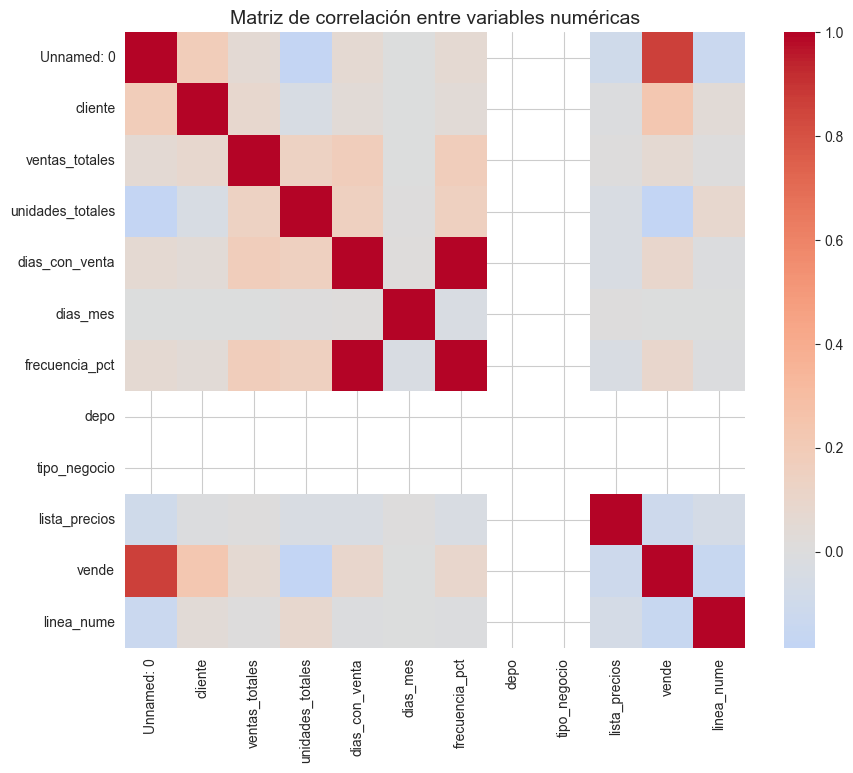

Pares de variables con correlación alta (>0.85):


,var1,var2,corr
7,Unnamed: 0,vende,0.863506
31,dias_con_venta,frecuencia_pct,0.998214


In [115]:
# Exploración de correlaciones 

# Seleccionamos solo las variables numéricas candidatas al clustering
vars_cluster = df.select_dtypes(include=["float64", "int64"])

# calculamos la matriz
corr = vars_cluster.corr(method="pearson")

# Heatmap de correlación
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables numéricas", fontsize=14)
plt.show()

#mostrar pares muy correlacionados (>0.85)
umbral = 0.85
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["var1", "var2", "corr"]
print("Pares de variables con correlación alta (>0.85):")
display(corr_pairs[corr_pairs["corr"].abs() > umbral])


BORRRAMOS ENTONCES ALGUNA DE LAS 2 VARIABLES YA QUE INFLUIRÍA EN LAS DISTANCIAS DE LOS CLUSTERS?? Ver este punto ya que capaz no necesitemos borrarlas ya que después aplicamos PCA

##Técnica Kmeduias

In [81]:
RANDOM_STATE = 15
# Escalado + PCA (solo para representación; el clustering puede correr en Xz)

feat_vars = [
    "ventas_totales", "unidades_totales", "productos_distintos",
    "meses_presentes", "frecuencia_media", "dias_promedio", "ticket_promedio"
]

X = feat[feat_vars].values

# Estandarización
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# PCA (primeras 4 componentes para visualización y análisis)
pca = PCA(n_components=4, random_state=RANDOM_STATE)
Xp = pca.fit_transform(Xz)

# Guardamos para trazabilidad
pca_var = pca.explained_variance_ratio_.cumsum()

print("Shape X (raw):", X.shape)
print("Shape Xz (scaled):", Xz.shape)
print("Shape Xp (PCA):", Xp.shape)
print("Var. explicada acumulada (PCA):", pca_var)

# (Opcional) DataFrames auxiliares para inspección tabular en celdas separadas
Xz_df = pd.DataFrame(Xz, columns=[f"z_{c}" for c in feat_vars]).assign(cliente=feat["cliente"].values)
Xp_df = pd.DataFrame(Xp, columns=[f"PC{i+1}" for i in range(Xp.shape[1])]).assign(cliente=feat["cliente"].values)


Shape X (raw): (139, 7)
Shape Xz (scaled): (139, 7)
Shape Xp (PCA): (139, 4)
Var. explicada acumulada (PCA): [0.46948789 0.76212046 0.92073945 0.97919247]


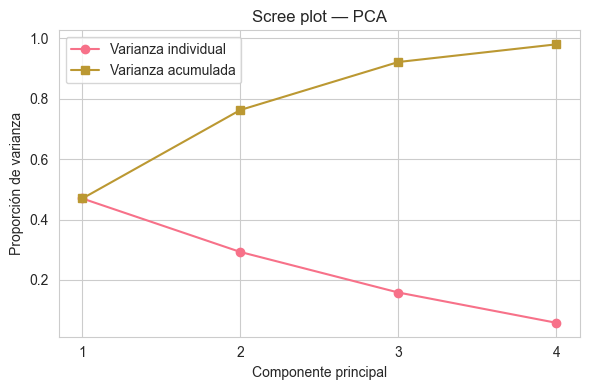

In [95]:
# Scree plot de la varianza explicada
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_,
         marker="o", label="Varianza individual")
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca_var, marker="s", label="Varianza acumulada")
plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza")
plt.title("Scree plot — PCA")
plt.legend()
plt.tight_layout()
plt.show()


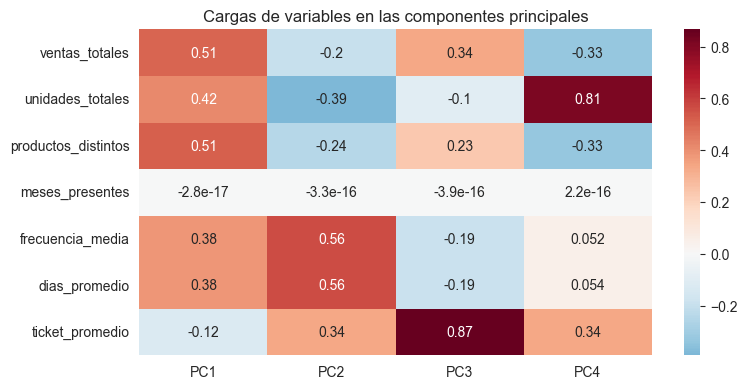

,PC1,PC2,PC3,PC4
ventas_totales,5.068643e-01,-1.986006e-01,3.377627e-01,-3.322146e-01
unidades_totales,4.161219e-01,-3.921891e-01,-1.019062e-01,8.137041e-01
productos_distintos,5.139997e-01,-2.400821e-01,2.347011e-01,-3.288703e-01
meses_presentes,-2.775558e-17,-3.330669e-16,-3.885781e-16,2.220446e-16
frecuencia_media,3.815393e-01,5.625407e-01,-1.870631e-01,5.181822e-02
dias_promedio,3.807637e-01,5.632936e-01,-1.873196e-01,5.413499e-02
ticket_promedio,-1.232161e-01,3.396387e-01,8.662365e-01,3.372650e-01


In [96]:
# Loadings (cargas de las variables en cada PC)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feat_vars
)

plt.figure(figsize=(8,4))
sns.heatmap(loadings, annot=True, cmap="RdBu_r", center=0)
plt.title("Cargas de variables en las componentes principales")
plt.tight_layout()
plt.show()

loadings


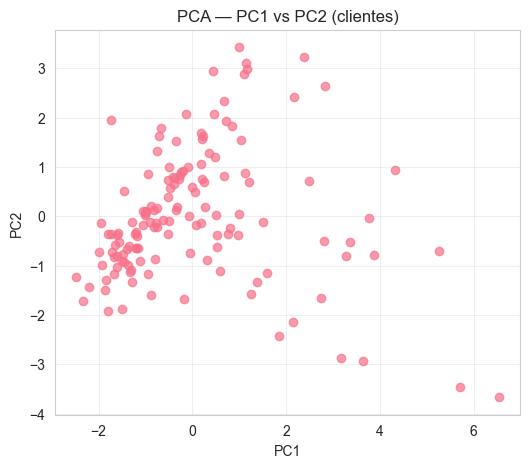

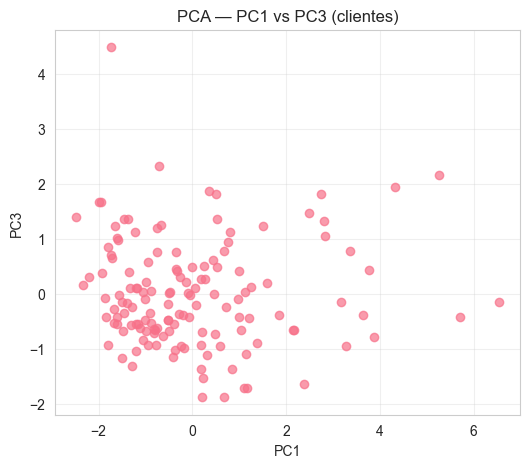

In [97]:
# Scatter PCA (PC1 vs PC2 y PC1 vs PC3)
plt.figure(figsize=(6,5))
plt.scatter(Xp[:,0], Xp[:,1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA — PC1 vs PC2 (clientes)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Xp[:,0], Xp[:,2], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.title("PCA — PC1 vs PC3 (clientes)")
plt.grid(True, alpha=0.3)
plt.show()


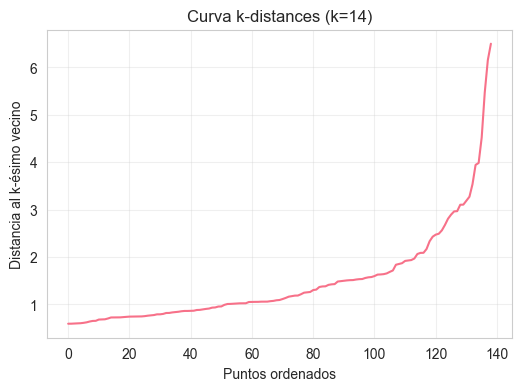

In [85]:
# Curva k-distances para estimar eps de DBSCAN
from sklearn.neighbors import NearestNeighbors

# regla práctica: min_samples ≈ 2*dimensión
k = Xz.shape[1] * 2

nbrs = NearestNeighbors(n_neighbors=k)
nbrs_fit = nbrs.fit(Xz)
distances, indices = nbrs_fit.kneighbors(Xz)

# Tomamos la distancia al k-ésimo vecino
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(kdist)
plt.title(f"Curva k-distances (k={k})")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al k-ésimo vecino")
plt.grid(True, alpha=0.3)
plt.show()


In [86]:
# Exploración de eps candidatos para DBSCAN
from sklearn.cluster import DBSCAN

candidatos = [80, 85, 88, 90, 92, 95]
res_eps = []

for q in candidatos:
    eps_i = float(np.percentile(kdist, q))
    labels = DBSCAN(eps=eps_i, min_samples=k, metric="euclidean").fit_predict(Xz)
    ruido = (labels == -1).mean() * 100
    n_clusters = len(np.unique(labels[labels != -1]))
    res_eps.append({
        "percentil": q,
        "eps": round(eps_i, 3),
        "clusters": n_clusters,
        "ruido_pct": round(ruido, 2)
    })

pd.DataFrame(res_eps)


,percentil,eps,clusters,ruido_pct
0,80,1.920,1,10.07
1,85,2.218,1,6.47
2,88,2.522,1,5.04
3,90,2.824,1,2.16
4,92,2.967,1,2.16
5,95,3.298,1,1.44


In [87]:
# Evaluar KMeans con distintas k y métricas
tabla_k = evaluar_kmeans(Xp, ks=range(2, 11))  # usamos Xp (PCA) para mayor estabilidad

print("\nResumen métricas por k (ordenado por silhouette):")
display(tabla_k.sort_values("silhouette", ascending=False).head(5))

# Heurísticas de sugerencia de k
k_sil = int(tabla_k.loc[tabla_k["silhouette"].idxmax(), "k"])
k_ch  = int(tabla_k.loc[tabla_k["calinski_harabasz"].idxmax(), "k"])
k_db  = int(tabla_k.loc[tabla_k["davies_bouldin"].idxmin(),  "k"])

print(f"\nSugerencias de k → sil:{k_sil} | ch:{k_ch} | db:{k_db}")



Resumen métricas por k (ordenado por silhouette):


,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.474490,67.015675,1.032276
7,9,0.333727,74.572156,0.823402
1,3,0.332607,76.138939,1.090133
6,8,0.314441,71.380535,0.875889
8,10,0.310986,74.130214,0.872296



Sugerencias de k → sil:2 | ch:3 | db:9


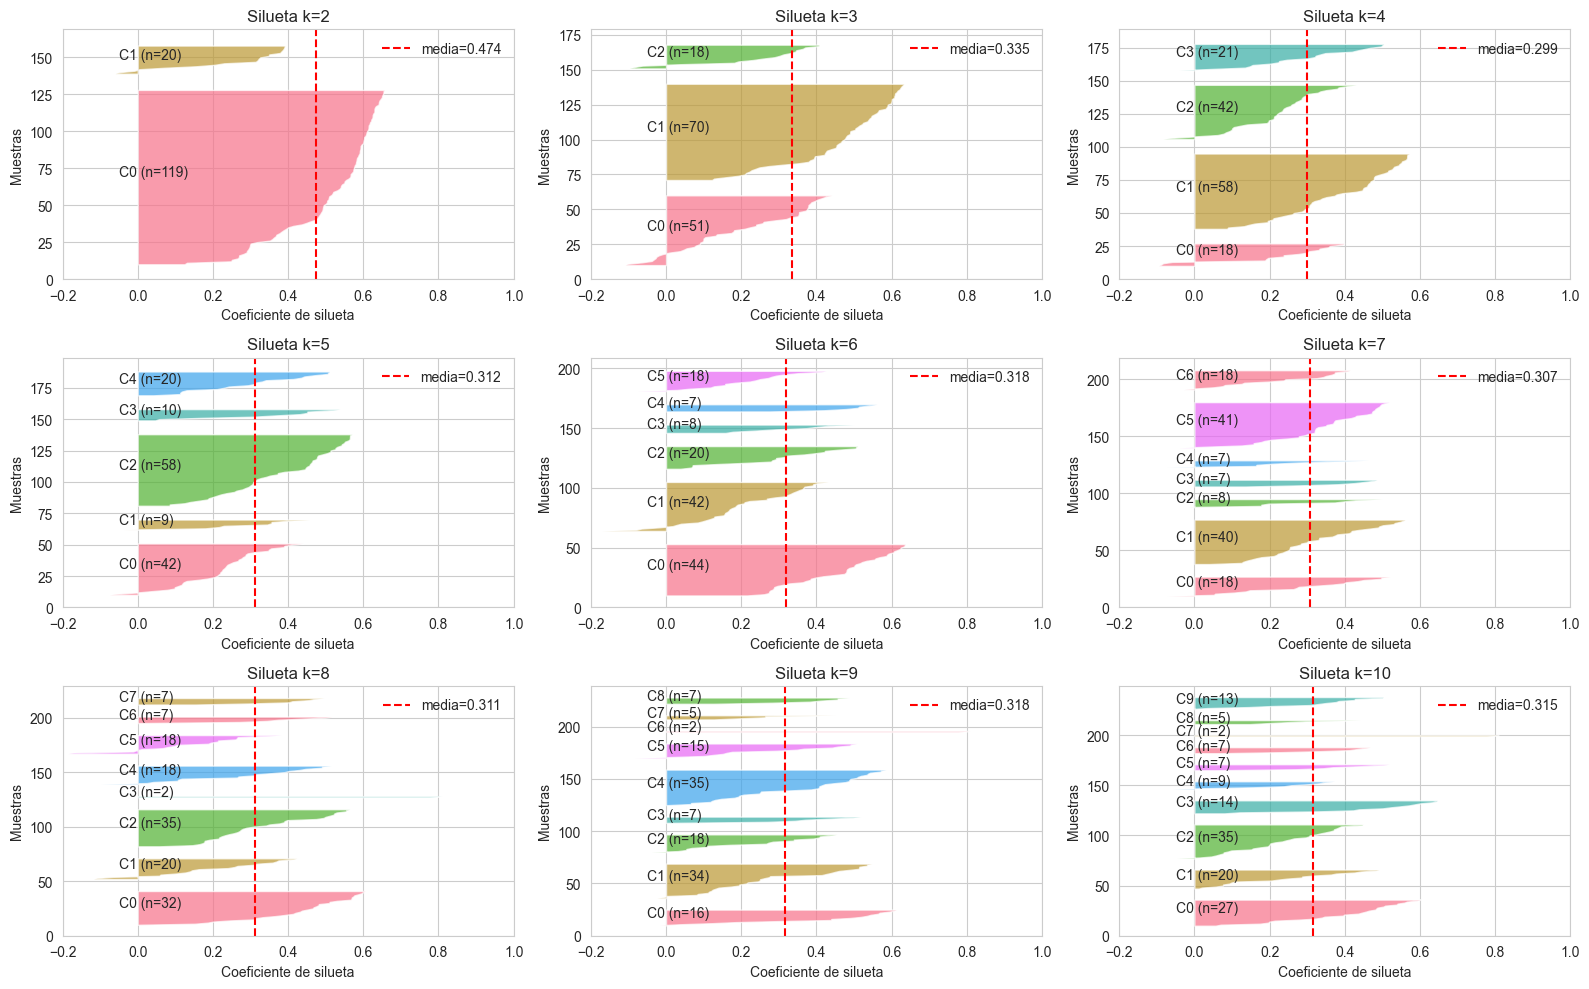

In [88]:
# Gráficos de silueta para varios k
plot_multi_silhouettes(Xp, ks=[2,3,4,5,6,7,8,9,10])


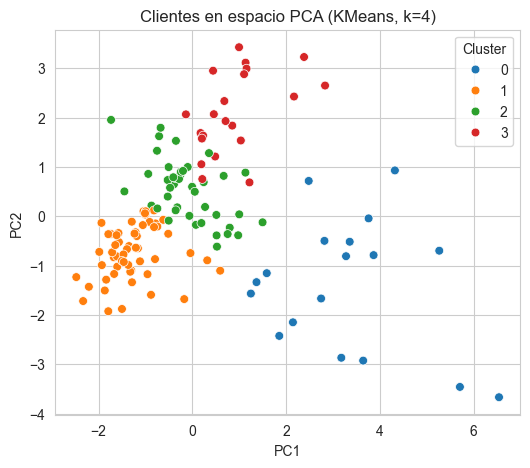

In [98]:
# KMeans final con K=5 (Puede ser  K=6 también, definir nosotros mas adelante)
k_final = 4
km = KMeans(n_clusters=k_final, n_init=20, random_state=RANDOM_STATE)
labels_km = km.fit_predict(Xp)

feat["cluster_id"] = labels_km

# Dispersión PCA
plt.figure(figsize=(6,5))
sns.scatterplot(x=Xp[:,0], y=Xp[:,1], hue=labels_km, palette="tab10", s=40)
plt.title(f"Clientes en espacio PCA (KMeans, k={k_final})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


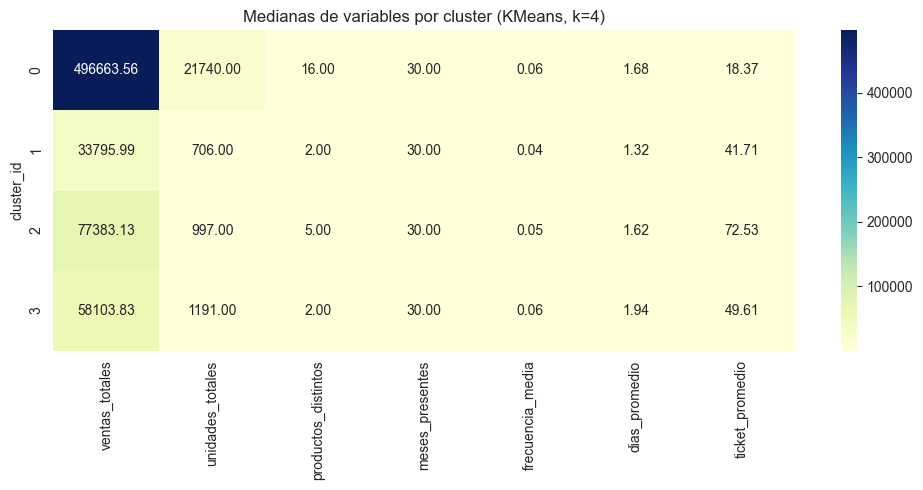

,ventas_totales,unidades_totales,productos_distintos,meses_presentes,frecuencia_media,dias_promedio,ticket_promedio
cluster_id,,,,,,,
0,496663.564305,21740.0,16.0,30.0,0.055421,1.683719,18.368529
1,33795.993029,706.0,2.0,30.0,0.043358,1.318182,41.706460
2,77383.131780,997.0,5.0,30.0,0.053401,1.622210,72.530349
3,58103.825116,1191.0,2.0,30.0,0.063929,1.940678,49.608200


In [99]:
# Perfilado de clusters (medianas por variable)
cols_num = [
    "ventas_totales","unidades_totales","productos_distintos",
    "meses_presentes","frecuencia_media","dias_promedio","ticket_promedio"
]

perfil = (feat
          .groupby("cluster_id")[cols_num]
          .median()
          .sort_index())

plt.figure(figsize=(10,5))
sns.heatmap(perfil, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Medianas de variables por cluster (KMeans, k={k_final})")
plt.tight_layout()
plt.show()

perfil


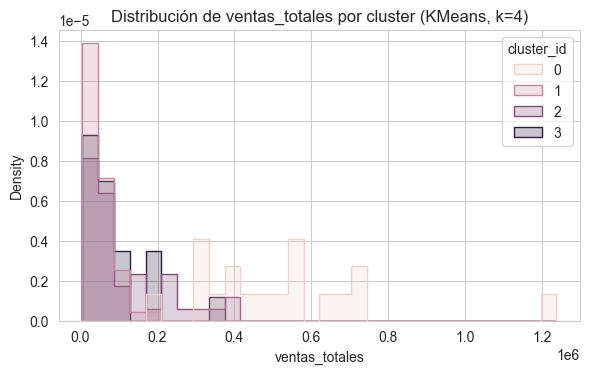

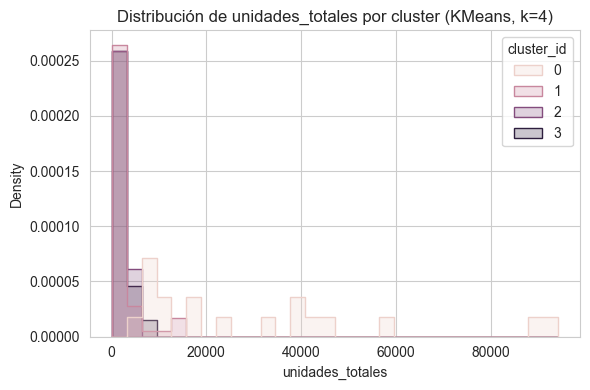

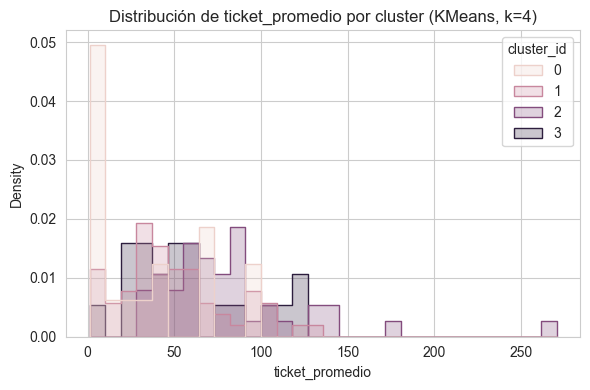

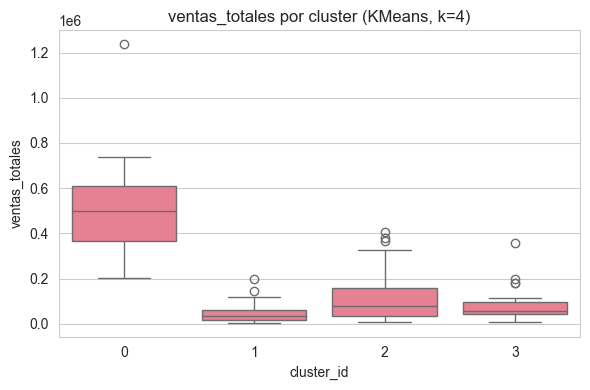

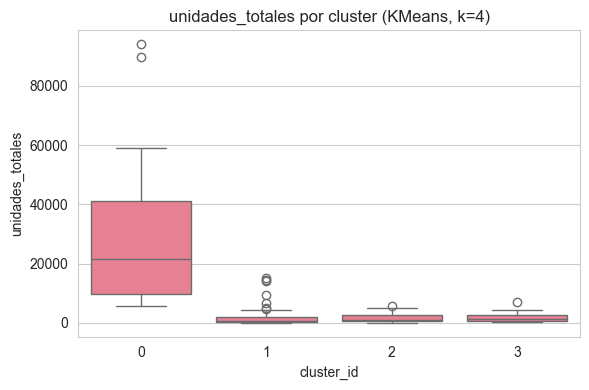

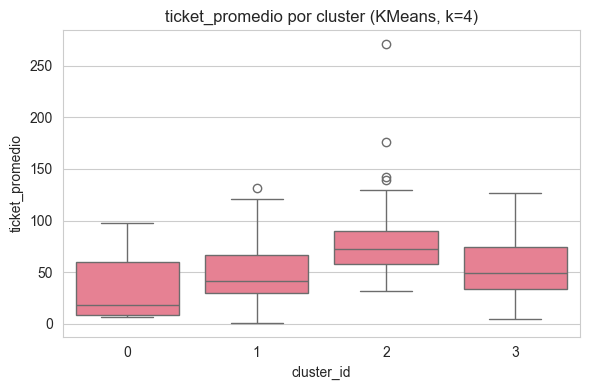

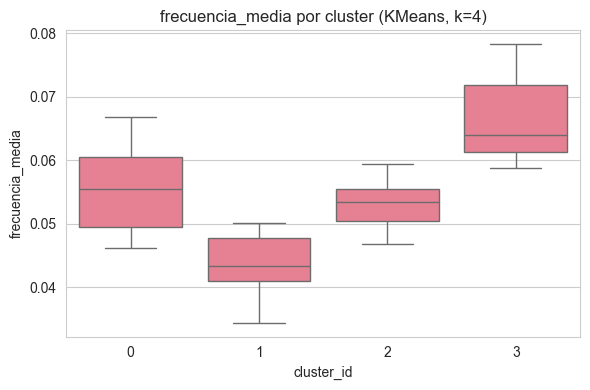

In [100]:
#  Distribuciones de variables clave por cluster

# Histogramas comparativos
vars_hist = ["ventas_totales", "unidades_totales", "ticket_promedio"]
for v in vars_hist:
    plt.figure(figsize=(6,4))
    sns.histplot(data=feat, x=v, hue="cluster_id", bins=30, element="step", stat="density", common_norm=False)
    plt.title(f"Distribución de {v} por cluster (KMeans, k={k_final})")
    plt.tight_layout()
    plt.show()

# Boxplots comparativos
vars_box = ["ventas_totales","unidades_totales","ticket_promedio","frecuencia_media"]
for v in vars_box:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=feat, x="cluster_id", y=v)
    plt.title(f"{v} por cluster (KMeans, k={k_final})")
    plt.tight_layout()
    plt.show()


In [92]:
# Top productos por cluster
# Merge df original (nivel transacción/mes) con los clusters finales
df_clusters = df.merge(feat[["cliente","cluster_id"]], on="cliente", how="left")

# Top productos por cluster según unidades totales
top_prods = (df_clusters.groupby(["cluster_id","produc"])["unidades_totales"]
             .sum()
             .reset_index()
             .sort_values(["cluster_id","unidades_totales"], ascending=[True,False]))

# Seleccionar top-5 de cada cluster
top5_by_cluster = top_prods.groupby("cluster_id").head(5)
top5_by_cluster


,cluster_id,produc,unidades_totales
80,0,000-000-3113,79525.0
26,0,000-000-11834,55800.0
24,0,000-000-11828,49410.0
74,0,000-000-2624,35945.0
75,0,000-000-2631,33970.0
137,1,000-000-13099,22400.0
144,1,000-000-13612,10443.0
151,1,000-000-3113,9540.0
129,1,000-000-11828,8100.0
146,1,000-000-1782,6776.0


In [ ]:
#HACER MAPA DE TELA ARAÑA

In [ ]:
# Guardamos la asignación de clusters (El profe lo pide en la consigna, ya los usaremos mas adelante)

clusters_out = (
    feat[["cliente", "cluster_id"]]
    .sort_values(["cluster_id", "cliente"])
    .reset_index(drop=True)
)


## 2) Sistema de Recomendación

In [111]:
#Acuerdensé de hacer copias de los df para no redefinir los dataframes originales
df = raw_df.copy()
df = df.merge(clusters_out, on="cliente", how="left")
print("Shape", df.shape)
print("Clientes unicos", df["cliente"].nunique())
print("Productos unicos", df["produc"].nunique())
print("Clusters", df["cluster_id"].nunique())

Shape (21060, 18)
Clientes unicos 139
Productos unicos 166
Clusters 4


Eje filas (entidad): cliente
Eje columnas (ítem): produc
Señal elegida: freq
Matriz: (68, 71)  (cliente × produc)
Sparsidad aprox.: 0.897


produc,000-000-10057,000-000-1009,000-000-10129,000-000-10130,000-000-10173,000-000-10174,000-000-10204,000-000-10340,000-000-10342,000-000-10885,000-000-11283,000-000-11554,000-000-11586,000-000-11646,000-000-11803,000-000-11809,000-000-11827,000-000-11828,000-000-11834,000-000-11913,000-000-12450,000-000-12490,000-000-12625,000-000-12882,000-000-12963,000-000-13099,000-000-13151,000-000-13216,000-000-13268,000-000-13296,000-000-13324,000-000-13325,000-000-13326,000-000-13348,000-000-13349,000-000-13358,000-000-13451,000-000-13612,000-000-13783,000-000-1732,000-000-1782,000-000-1999,000-000-2001,000-000-2170,000-000-3092,000-000-3113,000-000-3176,000-000-3274,000-000-3312,000-000-3313,000-000-3465,000-000-3466,000-000-3777,000-000-3870,000-000-3871,000-000-4013,000-000-4053,000-000-4056,000-000-5312,000-000-6020,000-000-6072,000-000-6074,000-000-6140,000-000-6596,000-000-6973,000-000-7049,000-000-7167,000-000-7198,000-000-8721,000-000-9341,000-000-9419
cliente,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
526,30.0,0.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,30.0,30.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0
901,30.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0
964,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,30.0
1299,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0


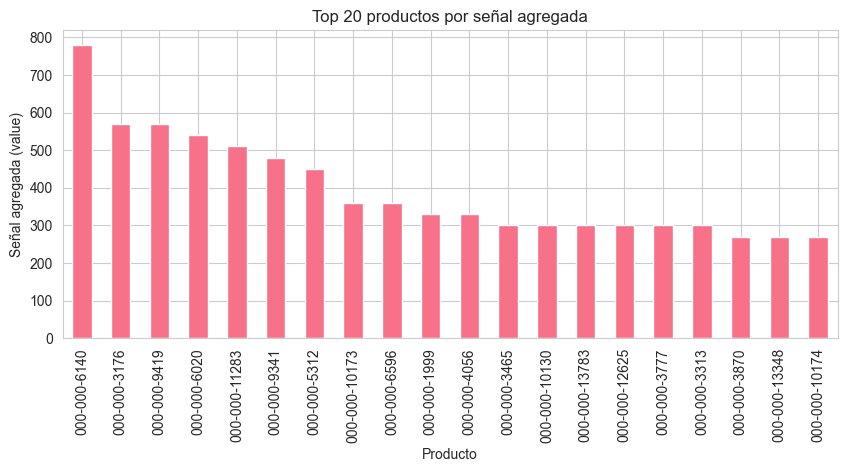

In [124]:
# matriz de interacciones para recomendador item-based ===
# matriz (PDV o cliente) × producto usando como señal la frecuencia de compra.



entity_col = 'pdv' if 'pdv' in df.columns else 'cliente'   # por consigna: PDV×SKU; fallback: cliente×SKU
item_col   = 'produc'                                      
signal     = 'freq'                                        # 'freq' | 'importe' | 'unidades'

print(f"Eje filas (entidad): {entity_col}")
print(f"Eje columnas (ítem): {item_col}")
print(f"Señal elegida: {signal}")

# Señal base (agregación)
if signal == 'freq':
    interactions = (
        df.groupby([entity_col, item_col])
          .size().reset_index(name='value')
    )
elif signal == 'importe' and 'importe' in df.columns:
    interactions = (
        df.groupby([entity_col, item_col])['importe']
          .sum().reset_index(name='value')
    )
elif signal == 'unidades' and 'canti_venta' in df.columns:
    interactions = (
        df.groupby([entity_col, item_col])['canti_venta']
          .sum().reset_index(name='value')
    )
else:
    # fallback seguro a frecuencia si la columna solicitada no existe
    interactions = (
        df.groupby([entity_col, item_col])
          .size().reset_index(name='value')
    )
    if signal != 'freq':
        print("La columna de señal no existe; se usará 'freq' (conteos).")

# Filtros mínimos para reducir ruido/sparsidad (ajustables)
min_items_per_entity  = 3   # cada entidad debe haber comprado al menos N productos
min_entities_per_item = 3   # cada producto debe aparecer en al menos N entidades

valid_entities = (
    interactions.groupby(entity_col)[item_col].nunique()
    .loc[lambda s: s >= min_items_per_entity]
).index

valid_items = (
    interactions.groupby(item_col)[entity_col].nunique()
    .loc[lambda s: s >= min_entities_per_item]
).index

interactions = interactions[
    interactions[entity_col].isin(valid_entities) &
    interactions[item_col].isin(valid_items)
].copy()

# Matriz utilidad (entidad × ítem)
matrix = (
    interactions
    .pivot(index=entity_col, columns=item_col, values='value')
    .fillna(0)
    .astype(float)
)

# check rápido
nonzeros = (matrix.values != 0).sum()
sparsity = 1 - (nonzeros / matrix.size)
print(f"Matriz: {matrix.shape}  ({entity_col} × {item_col})")
print(f"Sparsidad aprox.: {sparsity:.3f}")
display(matrix.head())

# 5) Vista rápida de popularidad de ítems (Top 20 por señal)
top_items = (
    interactions.groupby(item_col)['value'].sum()
    .sort_values(ascending=False).head(20)
)
ax = top_items.plot(kind='bar', figsize=(10,4), title='Top 20 productos por señal agregada')
ax.set_xlabel('Producto'); ax.set_ylabel('Señal agregada (value)')
plt.show()

# objetos para próximas celdas (similaridades)
X         = matrix.values            # matriz densa para cosenos
items     = matrix.columns.to_numpy()
entities  = matrix.index.to_numpy()


Armamos la matriz de interacciones cliente×producto usando frecuencia de compra como señal, aplicamos filtros mínimos para reducir ruido, calculamos su ""sparsidad"" (no se si existe la palabra) y graficamos el Top 20 de productos más comprados.
Resultados:
- trabajamos a nivel cliente × producto con señal de frecuencia → perfecto para item-based.

- Matriz 68×71 con sparsidad ~0.89: típico en recomendación; está bien para item-based.

- Fuerte concentración en pocos productos (p. ej., 000-000-6140 lidera); existe “larga cola” de ítems poco frecuentes.

- Los conteos uniformes (muchos 30) sugieren compras en lotes; no afecta el coseno pero explica barras similares.

Matriz de similitud ítem–ítem: (71, 71)


,000-000-10057,000-000-1009,000-000-10129,000-000-10130,000-000-10173
000-000-10057,0.000000,0.0,0.365148,0.387298,0.235702
000-000-1009,0.000000,0.0,0.000000,0.000000,0.000000
000-000-10129,0.365148,0.0,0.000000,0.707107,0.387298
000-000-10130,0.387298,0.0,0.707107,0.000000,0.365148
000-000-10173,0.235702,0.0,0.387298,0.365148,0.000000


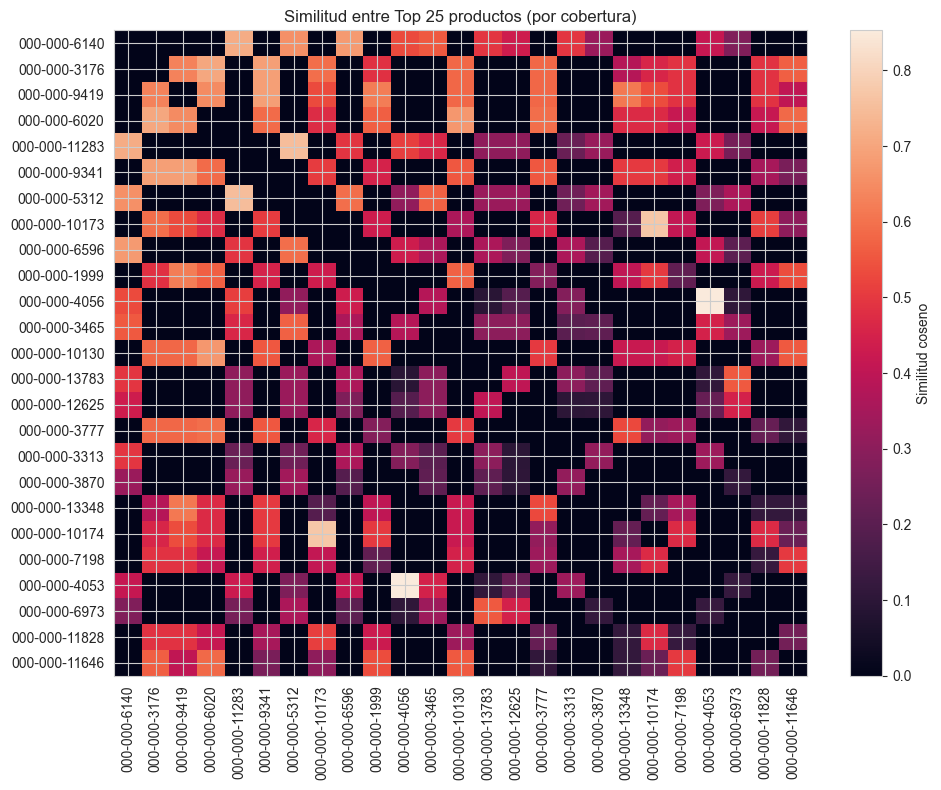

Ejemplo vecinos para: 000-000-6140


,similitud
000-000-11283,0.713477
000-000-6596,0.679366
000-000-5312,0.658281
000-000-3465,0.558156
000-000-4056,0.532181
000-000-13358,0.518875
000-000-6074,0.518875
000-000-13783,0.496139
000-000-3313,0.496139
000-000-11586,0.480384


In [118]:
# Similitud ítem–ítem (coseno) y chequeo visual

from sklearn.metrics.pairwise import cosine_similarity

# Similitud coseno entre columnas (productos)
# transponemos: items × entities
S = cosine_similarity(X.T)   # shape: (n_items, n_items)
np.fill_diagonal(S, 0.0)     # quitamos la auto-similitud
S = np.nan_to_num(S, nan=0.0, posinf=0.0, neginf=0.0)

S_df = pd.DataFrame(S, index=items, columns=items)

print("Matriz de similitud ítem–ítem:", S_df.shape)
display(S_df.iloc[:5, :5])

# Mapa de calor para los Top-N productos por popularidad
N = 25
top_items = (
    (matrix > 0).sum(axis=0)        # número de entidades que compraron cada producto
    .sort_values(ascending=False)
    .head(N).index
)
plt.figure(figsize=(10,8))
plt.imshow(S_df.loc[top_items, top_items].values, aspect='auto')
plt.colorbar(label='Similitud coseno')
plt.title(f"Similitud entre Top {N} productos (por cobertura)")
plt.xticks(ticks=np.arange(len(top_items)), labels=top_items, rotation=90)
plt.yticks(ticks=np.arange(len(top_items)), labels=top_items)
plt.tight_layout()
plt.show()

#función para consultar vecinos similares de un producto
def recomendar_similares(producto, k=10, min_sim=0.0):
    """
    Retorna los k productos más similares a 'producto' según coseno.
    - min_sim: umbral mínimo de similitud para filtrar ruido.
    """
    if producto not in S_df.index:
        raise ValueError(f"Producto {producto} no está en la matriz.")
    sims = S_df.loc[producto].copy()
    out = (sims[sims >= min_sim]
           .sort_values(ascending=False)
           .head(k))
    return out.to_frame(name='similitud')

# ejemplo
ejemplo = top_items[0] if len(top_items) > 0 else items[0]
print("Ejemplo vecinos para:", ejemplo)
display(recomendar_similares(ejemplo, k=10, min_sim=0.05))


Calculamos la similitud coseno ítem a ítem a partir de la matriz cliente×producto (transponiendo para comparar columnas),  armamos el DataFrame S_df (71×71) y visualizamos un heatmap para los Top-25 productos por cobertura.

Conclusiones clave

- La matriz de similitud está bien dimensionada (71×71) y sin auto-similitud (diagonal = 0).

- Hay pares muy cercanos: p. ej., 000-000-10129 ↔ 000-000-10130 ≈ 0.71, señal de co-compra fuerte.

- Existen ítems aislados (filas/columnas con muchos 0), como 000-000-1009, que tendrán menos poder para recomendar.

- El heatmap muestra bloques de productos relacionados; excelente para armar sustitutos/complementos en recomendaciones.

- recomendar_similares(producto, k) devuelve vecinos ordenados por coseno.

Ejemplo recomendaciones para cliente=296


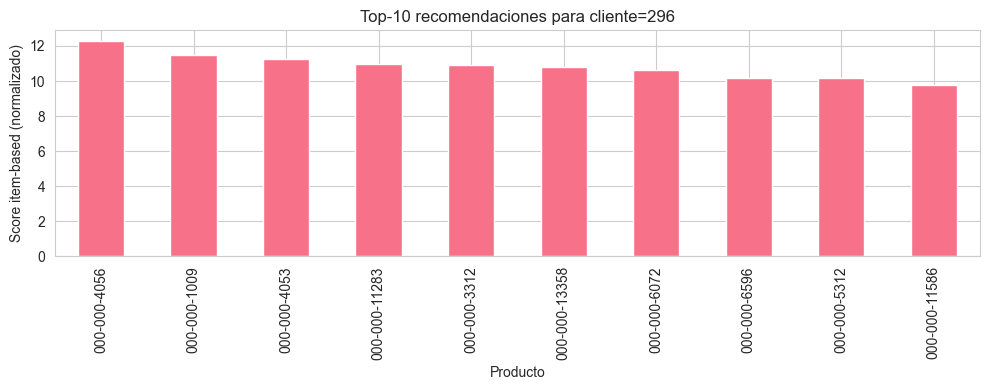

,produc,score,coverage
0,000-000-4056,12.273299,2.0
1,000-000-1009,11.503003,4.0
2,000-000-4053,11.271530,2.0
3,000-000-11283,10.987328,4.0
4,000-000-3312,10.932964,3.0
5,000-000-13358,10.785196,4.0
6,000-000-6072,10.626901,2.0
7,000-000-6596,10.161119,4.0
8,000-000-5312,10.146780,4.0
9,000-000-11586,9.798862,4.0


In [119]:
# recomendaciones por entidad (cliente/PDV) 

entity_col = 'pdv' if 'pdv' in df.columns else 'cliente'
item_col   = 'produc'


item_to_pos   = {it:i for i, it in enumerate(items)}
entity_to_pos = {e:i for i, e in enumerate(entities)}

#mapa de items por cluster para intra-cluster ---
has_cluster = ('cluster_id' in df.columns) and (df['cluster_id'].notna().any())

if has_cluster:
    # Items que existen por cluster (con cobertura mínima para evitar ruido)
    min_entities_per_item_cluster = 2
    df_ic = (
        df[[entity_col, item_col, 'cluster_id']]
        .dropna(subset=['cluster_id'])
        .drop_duplicates([entity_col, item_col, 'cluster_id'])
        .groupby(['cluster_id', item_col])[entity_col]
        .nunique()
        .reset_index(name='n_entities')
    )
    df_ic = df_ic[df_ic['n_entities'] >= min_entities_per_item_cluster]
    items_por_cluster = (
        df_ic.groupby('cluster_id')[item_col]
             .apply(set)
             .to_dict()
    )
else:
    items_por_cluster = {}

# matriz S con umbral opcional para filtrar similitudes débiles
def _masked_S(min_sim=0.0):
    if min_sim <= 0:
        return S
    M = S.copy()
    M[M < min_sim] = 0.0
    return M

def recomendar_para_entidad(entidad, k=10, min_sim=0.0, intra_cluster=False, plot=True):

    if entidad not in entity_to_pos:
        raise ValueError(f"{entity_col} {entidad} no está en la matriz.")

    pos_e = entity_to_pos[entidad]
    u = X[pos_e, :]                 # vector de interacciones de la entidad (1 × n_items)

    # Máscara de items ya comprados (no recomendar repetidos)
    bought_mask = u > 0

    # Similitudes con umbral
    Sm = _masked_S(min_sim=min_sim)
    scores = u @ Sm                 # (n_items,)

    # Normalización opcional por la suma de similitudes que aportan a cada j (para evitar sesgos)
    denom = (bought_mask.astype(float) @ (Sm > 0).astype(float))  # cuántos vecinos contribuyen a cada j
    denom = np.where(denom == 0, 1.0, denom)
    scores = scores / denom

    # Nunca recomendar lo ya comprado
    scores = np.where(bought_mask, -np.inf, scores)

    # Filtro intra-cluster (si aplica)
    if intra_cluster and has_cluster:
        cluster_e = (
            df.loc[df[entity_col] == entidad, 'cluster_id']
              .dropna()
        )
        if len(cluster_e) > 0:
            c_id = cluster_e.mode().iloc[0]
            cand = items_por_cluster.get(c_id, set())
            mask_cluster = np.array([ (it in cand) for it in items ])
            scores = np.where(mask_cluster, scores, -np.inf)

    # Top-k
    top_idx = np.argsort(scores)[::-1][:k]
    top_items = items[top_idx]
    top_scores = scores[top_idx]

    # Cobertura (# de items comprados que aportan al score)
    coverage = (bought_mask.astype(float) @ (Sm[:, top_idx] > 0).astype(float))

    out = pd.DataFrame({
        item_col: top_items,
        'score':  top_scores,
        'coverage': coverage
    }).replace([np.inf, -np.inf], np.nan).dropna(subset=['score'])

    # Visual
    if plot and len(out) > 0:
        plt.figure(figsize=(10,4))
        out.set_index(item_col)['score'].plot(kind='bar')
        plt.title(f"Top-{k} recomendaciones para {entity_col}={entidad}")
        plt.xlabel("Producto"); plt.ylabel("Score item-based (normalizado)")
        plt.tight_layout(); plt.show()

    return out.sort_values('score', ascending=False)

# check
ejemplo_entidad = entities[0]
print(f"Ejemplo recomendaciones para {entity_col}={ejemplo_entidad}")
display(recomendar_para_entidad(ejemplo_entidad, k=10, min_sim=0.05, intra_cluster=False, plot=True))


Generamos para el cliente 296 su Top-10 de recomendaciones con un item-based coseno: usamos sus compras como “anclas”, combinamos similitudes con los ítems no comprados, normalizamos el score y excluimos lo ya comprado.

Conclusiones

- Confianza alta: scores ~9.8–12.3; los más fuertes: 000-000-4056, 000-000-1009, 000-000-4053.
- Soporte real: coverage entre 2 y 4 indica que varias compras previas respaldan cada recomendación (menos riesgo).
- Equilibrio popularidad-afinidad: aparecen ítems frecuentes pero también relacionados por co-compra.

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)


Recomendando: 100%|██████████| 68/68 [00:00<00:00, 130.36it/s]

Recomendaciones generadas: (680, 5)


,entidad,producto,score,coverage,rank
0,296,000-000-4056,12.273299,2.0,1
1,296,000-000-1009,11.503003,4.0,2
2,296,000-000-4053,11.271530,2.0,3
3,296,000-000-11283,10.987328,4.0,4
4,296,000-000-3312,10.932964,3.0,5


Archivo guardado: recos_item_based_top10.csv


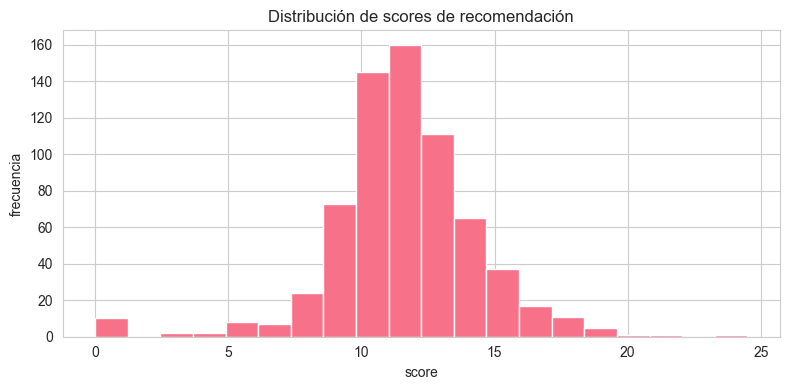

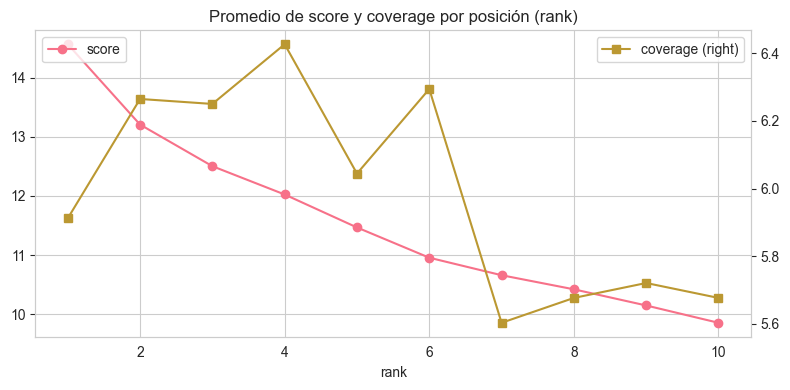

Explicabilidad para entidad=296, producto=000-000-4056


,item_comprado,sim,peso,rank
0,000-000-6140,0.532181,15.965435,1
1,000-000-3313,0.286039,8.581163,2


In [ ]:
# Generar recomendaciones para TODAS las entidades y guardar
# !pip install tqdm
from tqdm.auto import tqdm

def explicar_contribucion(entidad, producto_objetivo, top_m=5, min_sim=0.0):
    """
    Explica qué ítems COMPRADOS por la entidad más contribuyen al score del producto recomendado.
    Devuelve un DataFrame con columnas: item_comprado, sim, peso (u_i * sim), y ranking.
    """
    if entidad not in entity_to_pos:
        raise ValueError(f"{entity_col} {entidad} no está en la matriz.")
    if producto_objetivo not in item_to_pos:
        raise ValueError(f"Producto {producto_objetivo} no está en la matriz.")

    e = entity_to_pos[entidad]
    j = item_to_pos[producto_objetivo]

    u = X[e, :]                          # compras de la entidad
    bought_idx = np.where(u > 0)[0]      # índices de items comprados

    sims = S[bought_idx, j]              # similitud de cada item comprado con el objetivo
    if min_sim > 0:
        mask = sims >= min_sim
        bought_idx = bought_idx[mask]
        sims = sims[mask]

    pesos = u[bought_idx] * sims
    order = np.argsort(pesos)[::-1]
    bought_idx = bought_idx[order][:top_m]
    sims = sims[order][:top_m]
    pesos = pesos[order][:top_m]

    return pd.DataFrame({
        "item_comprado": items[bought_idx],
        "sim": sims,
        "peso": pesos,
        "rank": np.arange(1, len(pesos)+1)
    })

def generar_recos_batch(k=10, min_sim=0.05, intra_cluster=False):
    """
    Genera Top-k recomendaciones para todas las entidades.
    Retorna un DataFrame largo con columnas: entidad, producto, score, coverage, rank.
    """
    todas = []
    for ent in tqdm(entities, desc="Recomendando"):
        df_rec = recomendar_para_entidad(ent, k=k, min_sim=min_sim,
                                         intra_cluster=intra_cluster, plot=False)
        if len(df_rec) == 0:
            continue
        df_rec = df_rec.reset_index(drop=False).rename(columns={item_col: "producto"})
        df_rec.insert(0, "entidad", ent)
        df_rec["rank"] = np.arange(1, len(df_rec)+1)
        todas.append(df_rec[["entidad", "producto", "score", "coverage", "rank"]])
    if len(todas) == 0:
        return pd.DataFrame(columns=["entidad", "producto", "score", "coverage", "rank"])
    return pd.concat(todas, ignore_index=True)

# Generar recomendaciones en lote
recos_all = generar_recos_batch(k=10, min_sim=0.05, intra_cluster=False)
print("Recomendaciones generadas:", recos_all.shape)
display(recos_all.head())

# Guardar a CSV (para usar más adelante o compartir)
out_path = "recos_item_based_top10.csv"
recos_all.to_csv(out_path, index=False, encoding="utf-8")
print(f"Archivo guardado: {out_path}")

# Visualizaciones rápidas de diagnóstico
if len(recos_all) > 0:
    # Distribución de scores
    plt.figure(figsize=(8,4))
    recos_all["score"].plot(kind="hist", bins=20)
    plt.title("Distribución de scores de recomendación")
    plt.xlabel("score"); plt.ylabel("frecuencia")
    plt.tight_layout(); plt.show()

    # Coverage vs score (promedio por rank)
    tmp = recos_all.groupby("rank")[["score", "coverage"]].mean()
    ax = tmp["score"].plot(kind="line", figsize=(8,4), marker="o", label="score")
    ax2 = tmp["coverage"].plot(kind="line", marker="s", secondary_y=True, label="coverage")
    ax.set_title("Promedio de score y coverage por posición (rank)")
    ax.set_xlabel("rank")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.tight_layout(); plt.show()

# Ejemplo de explicabilidad
if len(recos_all) > 0:
    ejemplo_ent = recos_all.iloc[0]["entidad"]
    ejemplo_prod = recos_all.iloc[0]["producto"]
    print(f"Explicabilidad para entidad={ejemplo_ent}, producto={ejemplo_prod}")
    expl = explicar_contribucion(ejemplo_ent, ejemplo_prod, top_m=5, min_sim=0.05)
    display(expl)


Conclsuión:

Construimos matriz cliente×producto con señal de frecuencia.
Calculamos similitudes ítem–ítem (coseno).
Generamos Top-K por cliente, gráficos de control y explicabilidad (qué compras aportan al score). 
Exportamos recos_item_based_top10.csv. (No se si lo vamos a usar, ya veremos)

Hallazgos 
- Estructura sólida: matriz 68×71 con sparsing ~0.90 (normal en retail); el método item-based es apropiado.
- Relaciones claras entre productos: pares con coseno alto (p.ej. 10129↔10130 ≈ 0.71) ⇒ buen potencial de sustitución/upsell.
- Top-20 populares concentran demanda (p.ej. 000-000-6140) y sirven como “anclas” para recomendar a la larga cola.
- Recomendaciones con soporte real: en el ejemplo del cliente 296, coverage 2–4 vecinos por ítem ⇒ menor riesgo.
- Distribución de scores centrada ~10–12 y decrece con el rank ⇒ ranking consistente.

## 3) Ingeniería de series temporales

In [ ]:
#Generamos de vuelta df
df = raw_df.copy()

#Le agregamos los clusters nuevamente

key_entidad = 'pdv' if 'pdv' in df.columns and 'pdv' in clusters_out.columns else 'cliente'
df = df.merge(clusters_out[[key_entidad, 'cluster_id']].drop_duplicates(),
                on=key_entidad, how='left')

print("Shape", df.shape)
# print("Cols", sorted(df.columns.tolist()))


Shape (21060, 18)
Cols ['Unnamed: 0', 'cliente', 'cluster_id', 'condi_venta', 'depo', 'descrip', 'dias_con_venta', 'dias_mes', 'frecuencia_pct', 'linea_nume', 'lista_precios', 'mes', 'produc', 'sin_venta', 'tipo_negocio', 'unidades_totales', 'vende', 'ventas_totales']


In [136]:
# creamos series mensuales por (PDV o cliente) × producto con lags, diffs, MAs y calendario.

entity_col = 'pdv' if 'pdv' in df.columns else 'cliente'  # por consigna ideal: PDV×SKU
item_col   = 'produc'

# Señal objetivo para forecasting (prioridad: unidades > importe > frecuencia)
if 'canti_venta' in df.columns:
    target_signal = 'canti_venta'
    agg_fn = 'sum'
elif 'importe' in df.columns:
    target_signal = 'importe'
    agg_fn = 'sum'
else:
    target_signal = 'freq'  # conteo de transacciones
    agg_fn = 'size'

print(f"Granularidad: {entity_col} × {item_col} | Señal objetivo: {target_signal} ({agg_fn})")

# Columna de fecha 
date_candidates = ['mes']
date_col = date_candidates[0]

# Normalizamos a tipo datetime y a inicio-de-mes
df_dates = df.copy()
df_dates[date_col] = pd.to_datetime(df_dates[date_col])
df_dates['mes'] = df_dates[date_col].values.astype('datetime64[M]')  # periodo mensual (primer día del mes)

# -Agregación mensual por (entidad, item)
if target_signal == 'freq':
    grp = (df_dates
           .groupby([entity_col, item_col, 'mes'])
           .size().reset_index(name='y'))
else:
    grp = (df_dates
           .groupby([entity_col, item_col, 'mes'])[target_signal]
           .sum().reset_index(name='y'))

# completarmos grilla mensual (imputando faltantes como 0)
# Rango mensual global
min_month = grp['mes'].min()
max_month = grp['mes'].max()
all_months = pd.date_range(min_month, max_month, freq='MS')

# Grilla completa por par (entidad, item)
pairs = grp[[entity_col, item_col]].drop_duplicates()
pairs['_key'] = 1
cal = pd.DataFrame({'mes': all_months})
cal['_key'] = 1
grid = (pairs.merge(cal, on='_key', how='left')
              .drop(columns=['_key']))

ts = (grid.merge(grp, on=[entity_col, item_col, 'mes'], how='left')
           .fillna({'y': 0.0}))

# Features temporales (shift=1 para evitar fuga de info)
# Lags
for L in [1, 2, 3, 6, 12]:
    ts[f'lag_{L}'] = ts.groupby([entity_col, item_col])['y'].shift(L)

# Diffs
for D in [1, 12]:
    ts[f'diff_{D}'] = ts['y'] - ts.groupby([entity_col, item_col])['y'].shift(D)

# Moving averages (shift antes de promediar)
for W in [3, 6, 12]:
    ts[f'ma_{W}'] = (ts.groupby([entity_col, item_col])['y']
                       .shift(1)
                       .rolling(window=W, min_periods=1)
                       .mean())

# Calendario (mes, trimestre, año)
ts['month']   = ts['mes'].dt.month
ts['quarter'] = ts['mes'].dt.quarter
ts['year']    = ts['mes'].dt.year



# dropear NaN iniciales creados por lags 
cols_feat = [c for c in ts.columns if c not in [entity_col, item_col, 'mes', 'y']]
ts_clean = ts.dropna(subset=[c for c in cols_feat if c.startswith('lag_') or c.startswith('diff_')]).copy()

print("Panel final:", ts_clean.shape, "| columnas:", len(ts_clean.columns))
display(ts_clean.head())



Granularidad: cliente × produc | Señal objetivo: freq (size)
Panel final: (12636, 17) | columnas: 17


,cliente,produc,mes,y,lag_1,lag_2,lag_3,lag_6,lag_12,diff_1,diff_12,ma_3,ma_6,ma_12,month,quarter,year
12,296,000-000-3313,2023-01-01,1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1,1,2023
13,296,000-000-3313,2023-02-01,1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,2,1,2023
14,296,000-000-3313,2023-03-01,1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,3,1,2023
15,296,000-000-3313,2023-04-01,1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,4,2,2023
16,296,000-000-3313,2023-05-01,1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,5,2,2023


- Armamos un panel mensual cliente×producto con y = frecuencia de compra, completando meses faltantes con 0.
- Se generaron lags (1,2,3,6,12), diffs (1,12) y promedios móviles (3,6,12 con shift) + calendario; exactamente lo pedido en la consigna.
- Tamaño del panel: 12,636 filas / 17 columnas → suficiente para modelar.
- El ejemplo mostrado (cliente 296, producto 3313) tiene y=1 estable: lags y MAs ≈1 y diffs=0, lo que confirma que las features están alineadas y sin fuga de información (shift aplicado).

NaNs totales en ts_clean: 0


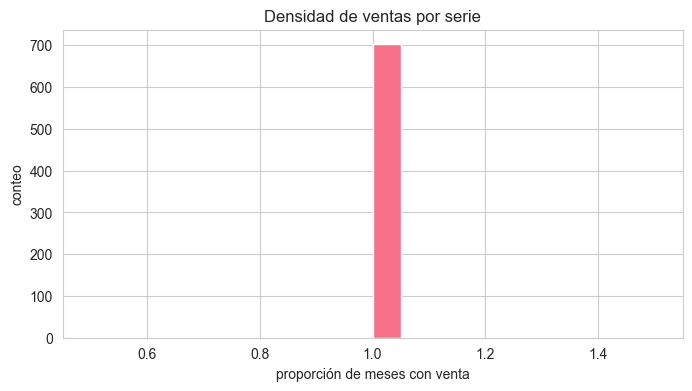

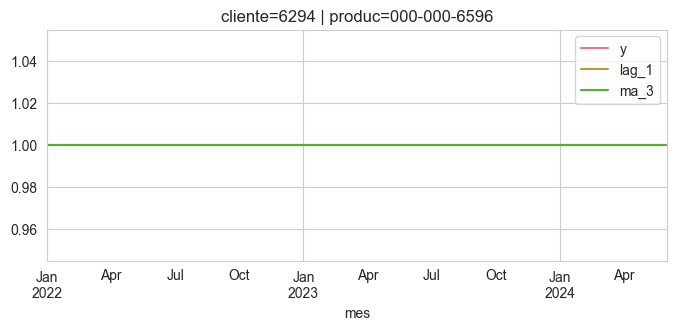

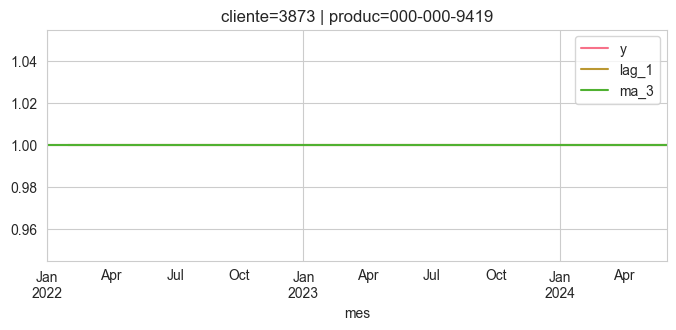

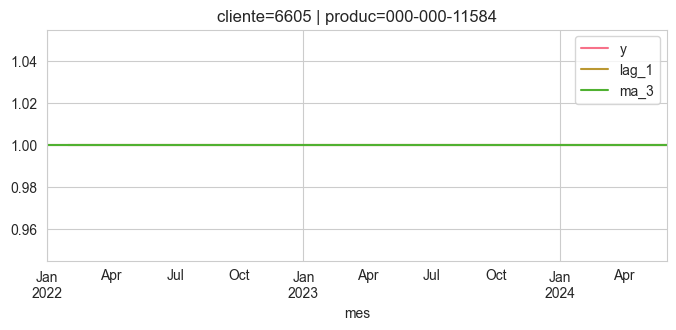

In [138]:
# check 1: densidad de ventas (meses con y>0) por par entidad×producto
densidad = (ts.groupby([entity_col, item_col])['y']
              .apply(lambda s: (s>0).mean())
              .reset_index(name='densidad'))
ax = densidad['densidad'].plot(kind='hist', bins=20, figsize=(8,4), title='Densidad de ventas por serie')
ax.set_xlabel('proporción de meses con venta'); ax.set_ylabel('conteo')

# check 2: ejemplo de 3 series al azar
muestra = (ts.groupby([entity_col, item_col]).size()
           .sample(3, random_state=7).index.tolist())
for e,i in muestra:
    tmp = ts[(ts[entity_col]==e) & (ts[item_col]==i)].sort_values('mes')
    tmp[['mes','y','lag_1','ma_3']].set_index('mes').plot(figsize=(8,3), title=f'{entity_col}={e} | {item_col}={i}')
    
# check 3: chequeo de NaNs en features (debería ser 0 tras el drop inicial)
na = ts_clean.isna().sum().sum()
print('NaNs totales en ts_clean:', na)


Conclusiones

- Sin NaNs: el panel ts_clean quedó consistente (0 NaNs).
- Densidad=1.0 en casi todas las series: para cada par cliente×producto hay venta todos los meses del rango → series muy estables.
- Ejemplos planos (y=1): lags, MAs y diffs reflejan esa estabilidad (lags≈1, diffs≈0).
- Implicación: modelos simples (naive/persistencia) pueden ser un baseline fuerte; para enriquecer variación, en el futuro podríamos usar importe/unidades en lugar de frecuencia o cambiar a PDV×SKU.

## 4) Forecasting

In [141]:
# Forecasting split H=6, baselines y métricas


panel = ts_clean.copy()  # viene completo ya


H = 6
keys = [entity_col, item_col]

def sMAPE(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1.0, denom)
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def MASE(y_true, y_pred, y_insample):
    y_true, y_pred, y_insample = map(np.asarray, (y_true, y_pred, y_insample))
    denom = np.mean(np.abs(y_insample[1:] - y_insample[:-1]))
    denom = 1.0 if denom == 0 else denom
    return np.mean(np.abs(y_true - y_pred)) / denom

def WAPE(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    denom = 1.0 if denom == 0 else denom
    return np.sum(np.abs(y_true - y_pred)) / denom

results = []
for (e,i), g in ts.sort_values('mes').groupby(keys):   # 👈 usar ts (no ts_clean)
    y = g['y'].values
    if len(y) <= H or (len(y) - H) < 2:               # 👈 requisito mínimo
        continue

    y_train = y[:-H]
    y_test  = y[-H:]

    # Baseline 1: último valor
    pred_last = np.repeat(y_train[-1], H)

    # Baseline 2: estacionalidad 12 (si no hay, usa último valor)
    if 'lag_12' in g.columns:
        pred_s12 = g['lag_12'].values[-H:]
    else:
        pred_s12 = np.full(H, np.nan)
    if np.isnan(pred_s12).any():
        pred_s12 = pred_last

    results.append({
        entity_col  : e,
        item_col    : i,
        'sMAPE_last': sMAPE(y_test, pred_last),
        'MASE_last' : MASE(y_test, pred_last, y_train),
        'WAPE_last' : WAPE(y_test, pred_last),
        'sMAPE_s12' : sMAPE(y_test, pred_s12),
        'MASE_s12'  : MASE(y_test, pred_s12, y_train),
        'WAPE_s12'  : WAPE(y_test, pred_s12),
    })

baseline_df = pd.DataFrame(results)
print("Series evaluadas:", baseline_df.shape[0])
display(baseline_df.head())

# Macro: promedio de las métricas disponibles
metric_cols = [c for c in baseline_df.columns if c.startswith(('sMAPE_','MASE_','WAPE_'))]
macro = baseline_df[metric_cols].mean().to_frame('macro')
print("\nMacro average:\n", macro)

baseline_df.to_csv("baseline_holdout6.csv", index=False)
print("Guardado: baseline_holdout6.csv")


Series evaluadas: 702


,cliente,produc,sMAPE_last,MASE_last,WAPE_last,sMAPE_s12,MASE_s12,WAPE_s12
0,296,000-000-3313,0.0,0.0,0.0,0.0,0.0,0.0
1,296,000-000-3870,0.0,0.0,0.0,0.0,0.0,0.0
2,296,000-000-3871,0.0,0.0,0.0,0.0,0.0,0.0
3,296,000-000-6140,0.0,0.0,0.0,0.0,0.0,0.0
4,526,000-000-10057,0.0,0.0,0.0,0.0,0.0,0.0



Macro average:
             macro
sMAPE_last    0.0
MASE_last     0.0
WAPE_last     0.0
sMAPE_s12     0.0
MASE_s12      0.0
WAPE_s12      0.0
Guardado: baseline_holdout6.csv
